# Evaluate the `droplet_reconstruction` pipeline step

This notebook evaluates the integration of `droplet_reconstruct.py` into XSpect as a
registered pipeline step (`XSpect/analysis/droplet.py`).

**What changed**
- New step `droplet_reconstruction` reconstructs per-shot 2D images from the
  `droplet_droplet2phot_sparse_*` arrays in the source smalldata HDF5.
- It supports both fixed-length (zero-padded) and variable-length sparse layouts,
  auto-detecting which is present.
- Batch manager now injects `abs_start_index` / `abs_end_index` so the step reads the
  correct HDF5 rows in batched mode.
- `max_shots:` in the YAML `data:` section limits shots loaded per run (for testing).

**Test config**: `mfx101609126_droplet_recon_test.yaml` reconstructs `epix100_0` for
run 79 (first 100 shots) using `roi: [270, 330, 400, 700]` — the same window stored in
`epix100_0/ROI_area` — then runs the standard XES chain (ADU threshold -> patch -> rotate
-> spatial reduce).

Each section prints a clear PASS/FAIL so you can judge correctness at a glance.

In [1]:
import sys, os
sys.path.insert(0, '..')

import importlib
import numpy as np
import h5py
import matplotlib.pyplot as plt

# NOTE: do NOT importlib.reload the XSpect droplet module here — the
# @register_step decorator raises 'already registered' on re-import. If you
# edit XSpect/analysis/droplet.py, restart the kernel to pick up changes.
from XSpect.controller.pipeline import Pipeline
from XSpect.analysis.registry import list_steps
from XSpect.analysis.droplet import _reconstruct_fixed, _reconstruct_var, PANEL_SHAPE

YAML = 'mfx101609126_droplet_recon_test.yaml'
SRC = '/sdf/data/lcls/ds/mfx/mfx101609126/hdf5/smalldata/mfx101609126_Run0079.h5'
ROI = (270, 330, 400, 700)   # rows 270-330, cols 400-700 -> (60, 300)

print('droplet_reconstruction registered:', 'droplet_reconstruction' in list_steps())

droplet_reconstruction registered: True


## 1. Run the full pipeline from YAML

Single-batch path (`batch_size` >> `max_shots`), mirroring `regenerate_run0079.py`.

In [2]:
pipeline = Pipeline.from_yaml(YAML)
pipeline.run(cores=1, batch_size=100000)

print('=== Step-by-step status ===')
for msg in pipeline.analyzed_runs[0].status:
    print(' ', msg)

print('\n=== Results (ndarrays) ===')
for k, v in pipeline.results.items():
    if isinstance(v, np.ndarray):
        print(f'  {k}: shape={v.shape} dtype={v.dtype} sum={np.nansum(v):.4g}')

=== Step-by-step status ===
  New analysis of run 79 located in: /sdf/data/lcls/ds/mfx/mfx101609126/hdf5/smalldata/mfx101609126_Run0079.h5
  HDF5 import of keys completed. Time: 0.02 seconds
  Obtained shot properties
  Running step: droplet_reconstruction
  droplet_reconstruction: 'epix100_0' -> 'epix_spec' shape=(100, 60, 300) roi=(270, 330, 400, 700) shots=[0,100) elapsed=0.2s
  Completed step: droplet_reconstruction
  Running step: union_shots
  Union shots: xrt_hproj with masks ['xray', 'xray'] -> xrt_hproj (8 shots)
  Completed step: union_shots
  Running step: union_shots
  Union shots: ipm with masks ['xray', 'xray'] -> ipm (8 shots)
  Completed step: union_shots
  Running step: union_shots
  Union shots: epix_spec with masks ['xray', 'xray'] -> epix_spec (8 shots)
  Completed step: union_shots
  Running step: filter_detector_adu
  ADU filtered epix_spec with threshold 5.0
  Completed step: filter_detector_adu
  Running step: patch_pixels
  Patched 9 pixels on epix_spec (axis=2

## 2. Cross-check against the standalone reference module

The integrated step must produce bit-identical images to the original
`droplet_reconstruct.DropletReconstructor` for the same shots and ROI.

In [3]:
import droplet_reconstruct
importlib.reload(droplet_reconstruct)
from droplet_reconstruct import DropletReconstructor, ROIS

rec = DropletReconstructor(SRC)
with h5py.File(SRC, 'r') as fh:
    mine = _reconstruct_fixed(fh, 'epix100_0', 0, 20, ROI, PANEL_SHAPE)
ref = rec.reconstruct_many('epix100_0', list(range(20)), roi=ROI)
rec.close()

ok = np.array_equal(mine, ref)
print(f'epix100_0 (fixed-length)  identical to reference: {ok}')
print(f'  total photons  mine={mine.sum():.0f}  ref={ref.sum():.0f}')
print('PASS' if ok else 'FAIL')

epix100_0 (fixed-length)  identical to reference: True
  total photons  mine=9571  ref=9571
PASS


## 3. Verify shot alignment against `ROI_area`

The reconstructed images should be perfectly shot-aligned with the pre-processed
`epix100_0/ROI_area` dataset. Per-shot total-signal correlation should be ~1.0.

ROI_area shape (100, 60, 300)  recon shape (100, 60, 300)
Per-shot signal correlation: 1.0000
PASS


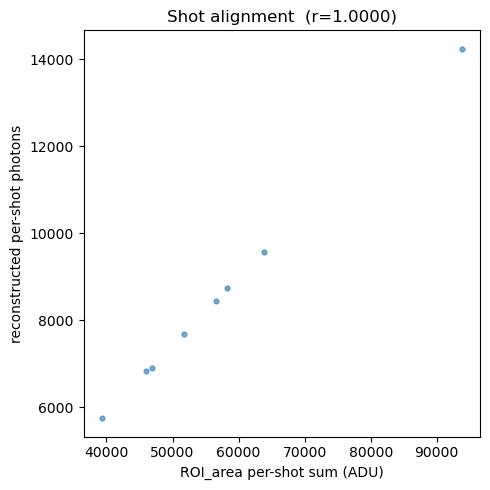

In [4]:
with h5py.File(SRC, 'r') as fh:
    recon = _reconstruct_fixed(fh, 'epix100_0', 0, 100, ROI, PANEL_SHAPE)
    roi_area = fh['epix100_0/ROI_area'][0:100]

recon_tot = recon.sum(axis=(1, 2))
roi_tot = np.clip(roi_area, 0, None).sum(axis=(1, 2))
m = roi_tot > 0
corr = np.corrcoef(recon_tot[m], roi_tot[m])[0, 1]
print(f'ROI_area shape {roi_area.shape}  recon shape {recon.shape}')
print(f'Per-shot signal correlation: {corr:.4f}')
print('PASS' if corr > 0.99 else 'FAIL')

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(roi_tot[m], recon_tot[m], s=12, alpha=0.6)
ax.set_xlabel('ROI_area per-shot sum (ADU)')
ax.set_ylabel('reconstructed per-shot photons')
ax.set_title(f'Shot alignment  (r={corr:.4f})')
plt.tight_layout(); plt.show()

## 4. Verify batched slicing is consistent

Reconstructing `[0,100)` in one pass must equal reconstructing `[0,30)+[30,60)+[60,100)`
as separate batches. This exercises the `abs_start_index`/`abs_end_index` logic the
batch manager relies on.

In [5]:
with h5py.File(SRC, 'r') as fh:
    full = _reconstruct_fixed(fh, 'epix100_0', 0, 100, ROI, PANEL_SHAPE)
    b1 = _reconstruct_fixed(fh, 'epix100_0', 0, 30, ROI, PANEL_SHAPE)
    b2 = _reconstruct_fixed(fh, 'epix100_0', 30, 60, ROI, PANEL_SHAPE)
    b3 = _reconstruct_fixed(fh, 'epix100_0', 60, 100, ROI, PANEL_SHAPE)

stacked = np.concatenate([b1, b2, b3], axis=0)
ok = np.array_equal(full, stacked)
print(f'batched concat == full reconstruction: {ok}')
print('PASS' if ok else 'FAIL')

batched concat == full reconstruction: True
PASS


## 5. ROI-direct scattering is bit-identical and cheaper

When a `roi` is given, photons are filtered to the ROI window and scattered straight
into the small cropped image (`_scatter_roi`) — the full 704x768 panel is never
allocated. This must be **bit-identical** to the old `_scatter(...)[r0:r1, c0:c1]`
approach, while using far less memory.

In [6]:
import time, tracemalloc
from XSpect.analysis.droplet import _scatter, _scatter_roi

# Preload photons for 200 shots so we time only the scatter
shots = []
with h5py.File(SRC, 'r') as fh:
    g = 'epix100_0/droplet_droplet2phot_sparse'
    for idx in range(200):
        row = fh[f'{g}_row'][idx].astype(np.float64)
        col = fh[f'{g}_col'][idx].astype(np.float64)
        dat = fh[f'{g}_data'][idx].astype(np.float64)
        v = dat != 0
        shots.append((row[v], col[v], dat[v]))

# Bit-identical check
identical = all(
    np.array_equal(
        _scatter(r, c, d, PANEL_SHAPE)[ROI[0]:ROI[1], ROI[2]:ROI[3]],
        _scatter_roi(r, c, d, ROI),
    )
    for r, c, d in shots
)
print(f'ROI-direct == full-panel-then-crop (200 shots): {identical}')
print('PASS' if identical else 'FAIL')

# Memory + speed
tracemalloc.start(); t0 = time.time()
for r, c, d in shots: _ = _scatter(r, c, d, PANEL_SHAPE)[ROI[0]:ROI[1], ROI[2]:ROI[3]]
t_old = time.time() - t0; _, peak_old = tracemalloc.get_traced_memory(); tracemalloc.stop()

tracemalloc.start(); t0 = time.time()
for r, c, d in shots: _ = _scatter_roi(r, c, d, ROI)
t_new = time.time() - t0; _, peak_new = tracemalloc.get_traced_memory(); tracemalloc.stop()

full_px = PANEL_SHAPE[0]*PANEL_SHAPE[1]; roi_px = (ROI[1]-ROI[0])*(ROI[3]-ROI[2])
print(f'Output pixels per shot:  full={full_px:,}  roi={roi_px:,}  ({full_px/roi_px:.0f}x smaller)')
print(f'Scatter time (200 shots): old={t_old*1e3:.1f}ms  new={t_new*1e3:.1f}ms  ({t_old/t_new:.1f}x faster)')
print(f'Peak alloc: old={peak_old/1e6:.2f}MB  new={peak_new/1e6:.2f}MB  ({peak_old/peak_new:.1f}x less)')

ROI-direct == full-panel-then-crop (200 shots): True
PASS


Output pixels per shot:  full=540,672  roi=18,000  (30x smaller)
Scatter time (200 shots): old=117.0ms  new=97.9ms  (1.2x faster)
Peak alloc: old=11.05MB  new=2.69MB  (4.1x less)


## 6. Visualize the reconstructed sum image and final spectrum

Left: summed reconstructed photons over the ROI (before rotation).
Right: the per-shot XES spectra produced by the full pipeline (`epix_spec_ROI_1`).

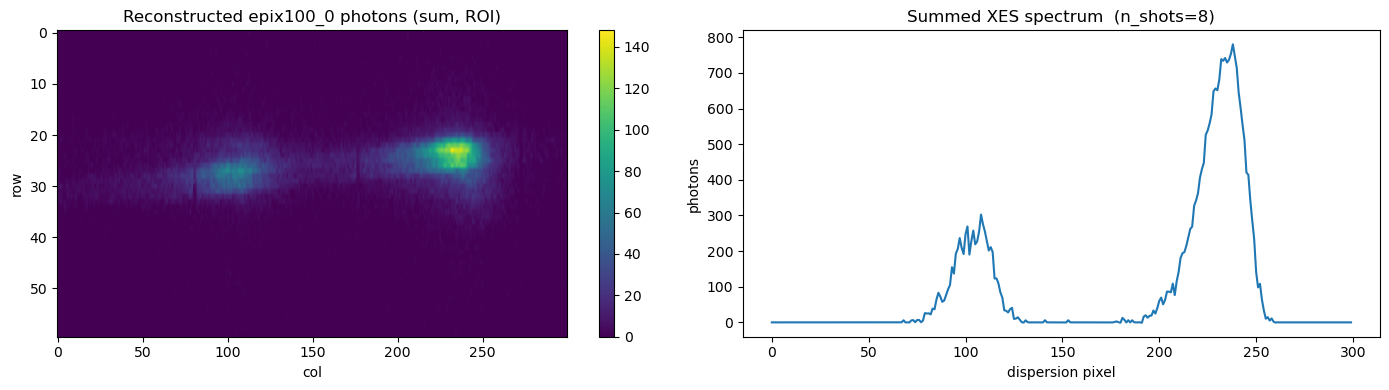

In [7]:
sum_img = recon.sum(axis=0)
spec = pipeline.results['epix_spec_ROI_1']   # (n_xray_shots, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
im = axes[0].imshow(sum_img, aspect='auto', cmap='viridis')
axes[0].set_title('Reconstructed epix100_0 photons (sum, ROI)')
axes[0].set_xlabel('col'); axes[0].set_ylabel('row')
fig.colorbar(im, ax=axes[0])

axes[1].plot(spec.sum(axis=0))
axes[1].set_title(f'Summed XES spectrum  (n_shots={spec.shape[0]})')
axes[1].set_xlabel('dispersion pixel'); axes[1].set_ylabel('photons')
plt.tight_layout(); plt.show()

## 7. Save results to HDF5

Writes `results/mfx101609126_droplet_recon_test/run0079.h5` (mirrors `regenerate_run0079.py`).

In [8]:
out_dir = pipeline.config.output.path
os.makedirs(out_dir, exist_ok=True)
run_num = pipeline.config.data.runs[0]
out_file = os.path.join(out_dir, f'run{run_num:04d}.h5')

with h5py.File(out_file, 'w') as f:
    for key, value in pipeline.results.items():
        if isinstance(value, np.ndarray):
            f.create_dataset(key, data=value)
            print(f'  saved: {key} {value.shape}')

print(f'\nWritten to: {out_file}')

  saved: ipm (8,)
  saved: xrt_hproj (8, 2048)
  saved: epix_spec_ROI_1 (8, 300)

Written to: ./results/mfx101609126_droplet_recon_test/run0079.h5
